In [1]:
import matplotlib.pyplot as plt  
import seaborn as sns
import pandas as pd
import numpy as np
import random
import math

In [2]:
def smooth(y,w=7,o=1,d=5):
    from scipy.signal import savgol_filter
    nans = [float('nan') for i in range(0,d)] 
    y = nans + list(savgol_filter(y[d:],w,o))
    for i in range(0,len(y)):
        if y[i]<0:
            y[i] = 0
    return y

In [3]:
# No regulation
d_nr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital'))
s_nr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital'))

# Weak regulation
d_wr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_low_sub'))
s_wr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_low_sub'))
# Weak regulation with lockout
d_wrl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_low_sub_lockout'))
s_wrl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_low_sub_lockout'))

# Moderate regulation
d_mr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_moderate_sub'))
s_mr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_moderate_sub'))
# Moderate regulation with lockout
d_mrl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_moderate_sub_lockout'))
s_mrl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_moderate_sub_lockout'))

# Strong regulation
d_sr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_high_sub'))
s_sr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_high_sub'))
# Strong regulation with lockout
d_srl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_high_sub_lockout'))
s_srl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_high_sub_lockout'))

<AxesSubplot:ylabel='P1_fare'>

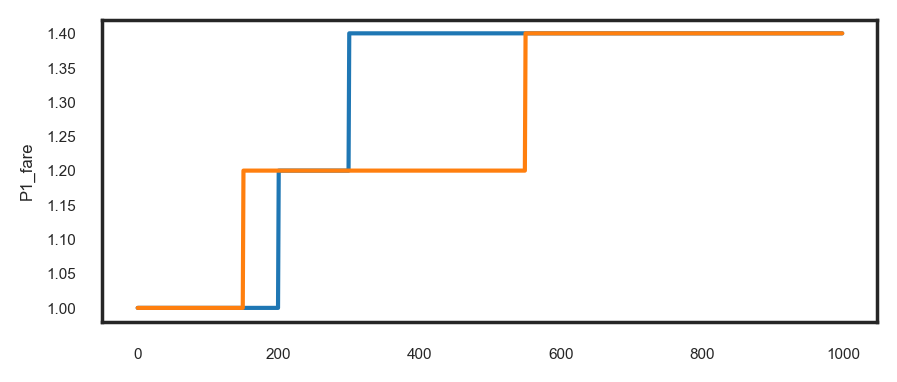

In [4]:
df = d_nr

sns.set(rc={"figure.dpi": 200, 'savefig.dpi': 200})
sns.set(palette='tab10', font_scale=0.5)
sns.set_style('white')
fig, ax = plt.subplots(figsize=(5, 2))
sns.lineplot(x=df.index, y=df.P1_fare)
sns.lineplot(x=df.index, y=df.P2_fare)


In [5]:
def s_1(y, w=7, o=1, d=5):
    from scipy.signal import savgol_filter
    if len(y) < w:
        raise ValueError("Input data length must be greater than or equal to the window size (w).")
    nans = [float('nan') for _ in range(0, d)]
    smoothed = savgol_filter(y[d:], w, o)
    y = nans + list(smoothed)
    return y

def s_2(y, w=27, o=1, d=5):
    from scipy.signal import savgol_filter
    if len(y) < w:
        raise ValueError("Input data length must be greater than or equal to the window size (w).")
    nans = [float('nan') for _ in range(0, d)]
    smoothed = savgol_filter(y[d:], w, o)
    y = nans + list(smoothed)
    return y

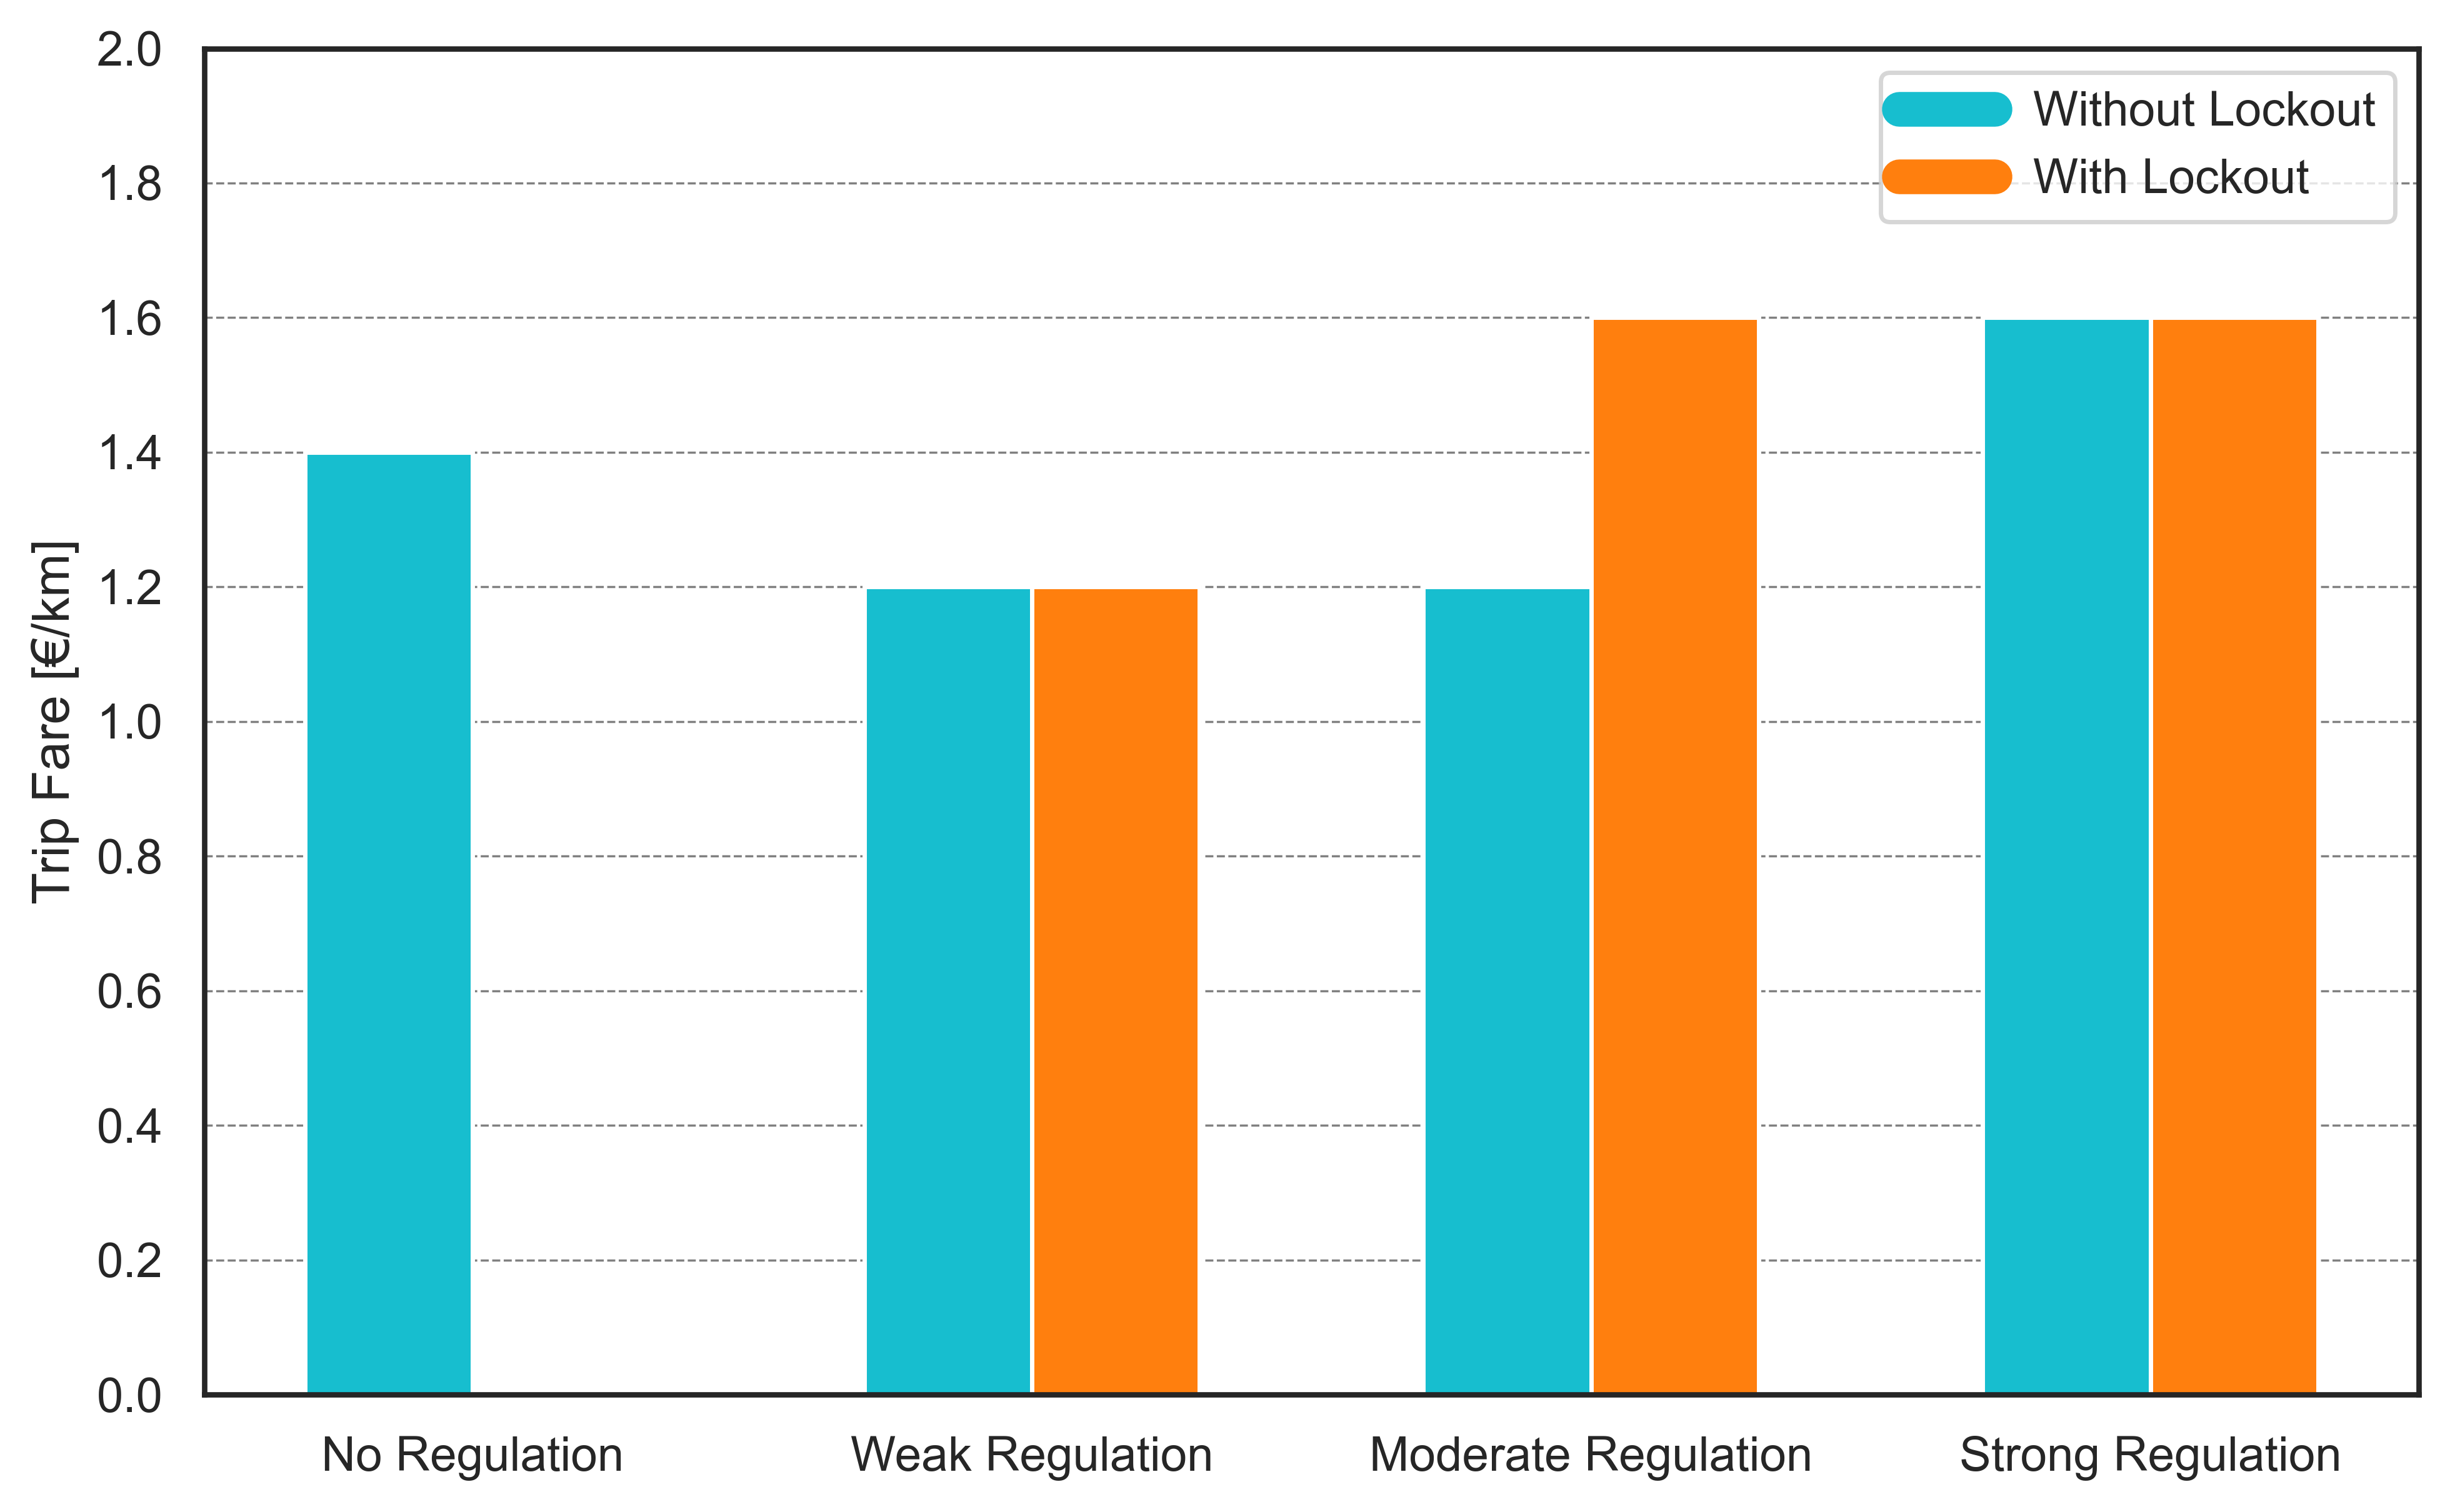

In [6]:
sns.set(rc={"figure.dpi": 500, 'savefig.dpi': 500})
sns.set(palette='tab10', font_scale=1.0)
sns.set_style('white')
fig, ax = plt.subplots(figsize=(8, 5))

c1 = 'C9'; c2 = 'C1'

groups = ['No Regulation', 'Weak Regulation', 'Moderate Regulation', 'Strong Regulation']
values_without_lockout = [1.4, 1.2, 1.2, 1.6]
values_with_lockout = [None, 1.2, 1.6, 1.6]  # None for the "No regulation" group where there is no "with lockout"

x = np.arange(len(groups))  # The label locations
width = 0.3  # Width of the bars

bars_without_lockout = ax.bar(x - width/2, values_without_lockout, width, label='Without Lockout', color=c1)

# Plot bars for "with lockout", skipping the first group
bars_with_lockout = [
    ax.bar(pos + width/2, value, width, color=c2, label='With Lockout' if i == 0 else "")
    for i, (pos, value) in enumerate(zip(x, values_with_lockout)) if value is not None
]

handles = [
    plt.Line2D([0], [0], color=c1, lw=8, label='Without Lockout'),
    plt.Line2D([0], [0], color=c2, lw=8, label='With Lockout')
]
ax.legend(handles=handles)
ax.set(xlabel='', ylabel='Trip Fare [€/km]', ylim=(0.0, 2.0))
ax.set_yticks(np.arange(0, 2.1, 0.2))
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(groups)

plt.tight_layout()
plt.savefig('Figs/1.2/P3_fig1.png')

In [7]:
d_nr.P1_profit

0     -500.00000
1     -500.00000
2     -452.44520
3     -436.96740
4     -422.55080
         ...    
995    110.13820
996     98.23120
997     80.86364
998    133.56972
999     95.54796
Name: P1_profit, Length: 1000, dtype: float64

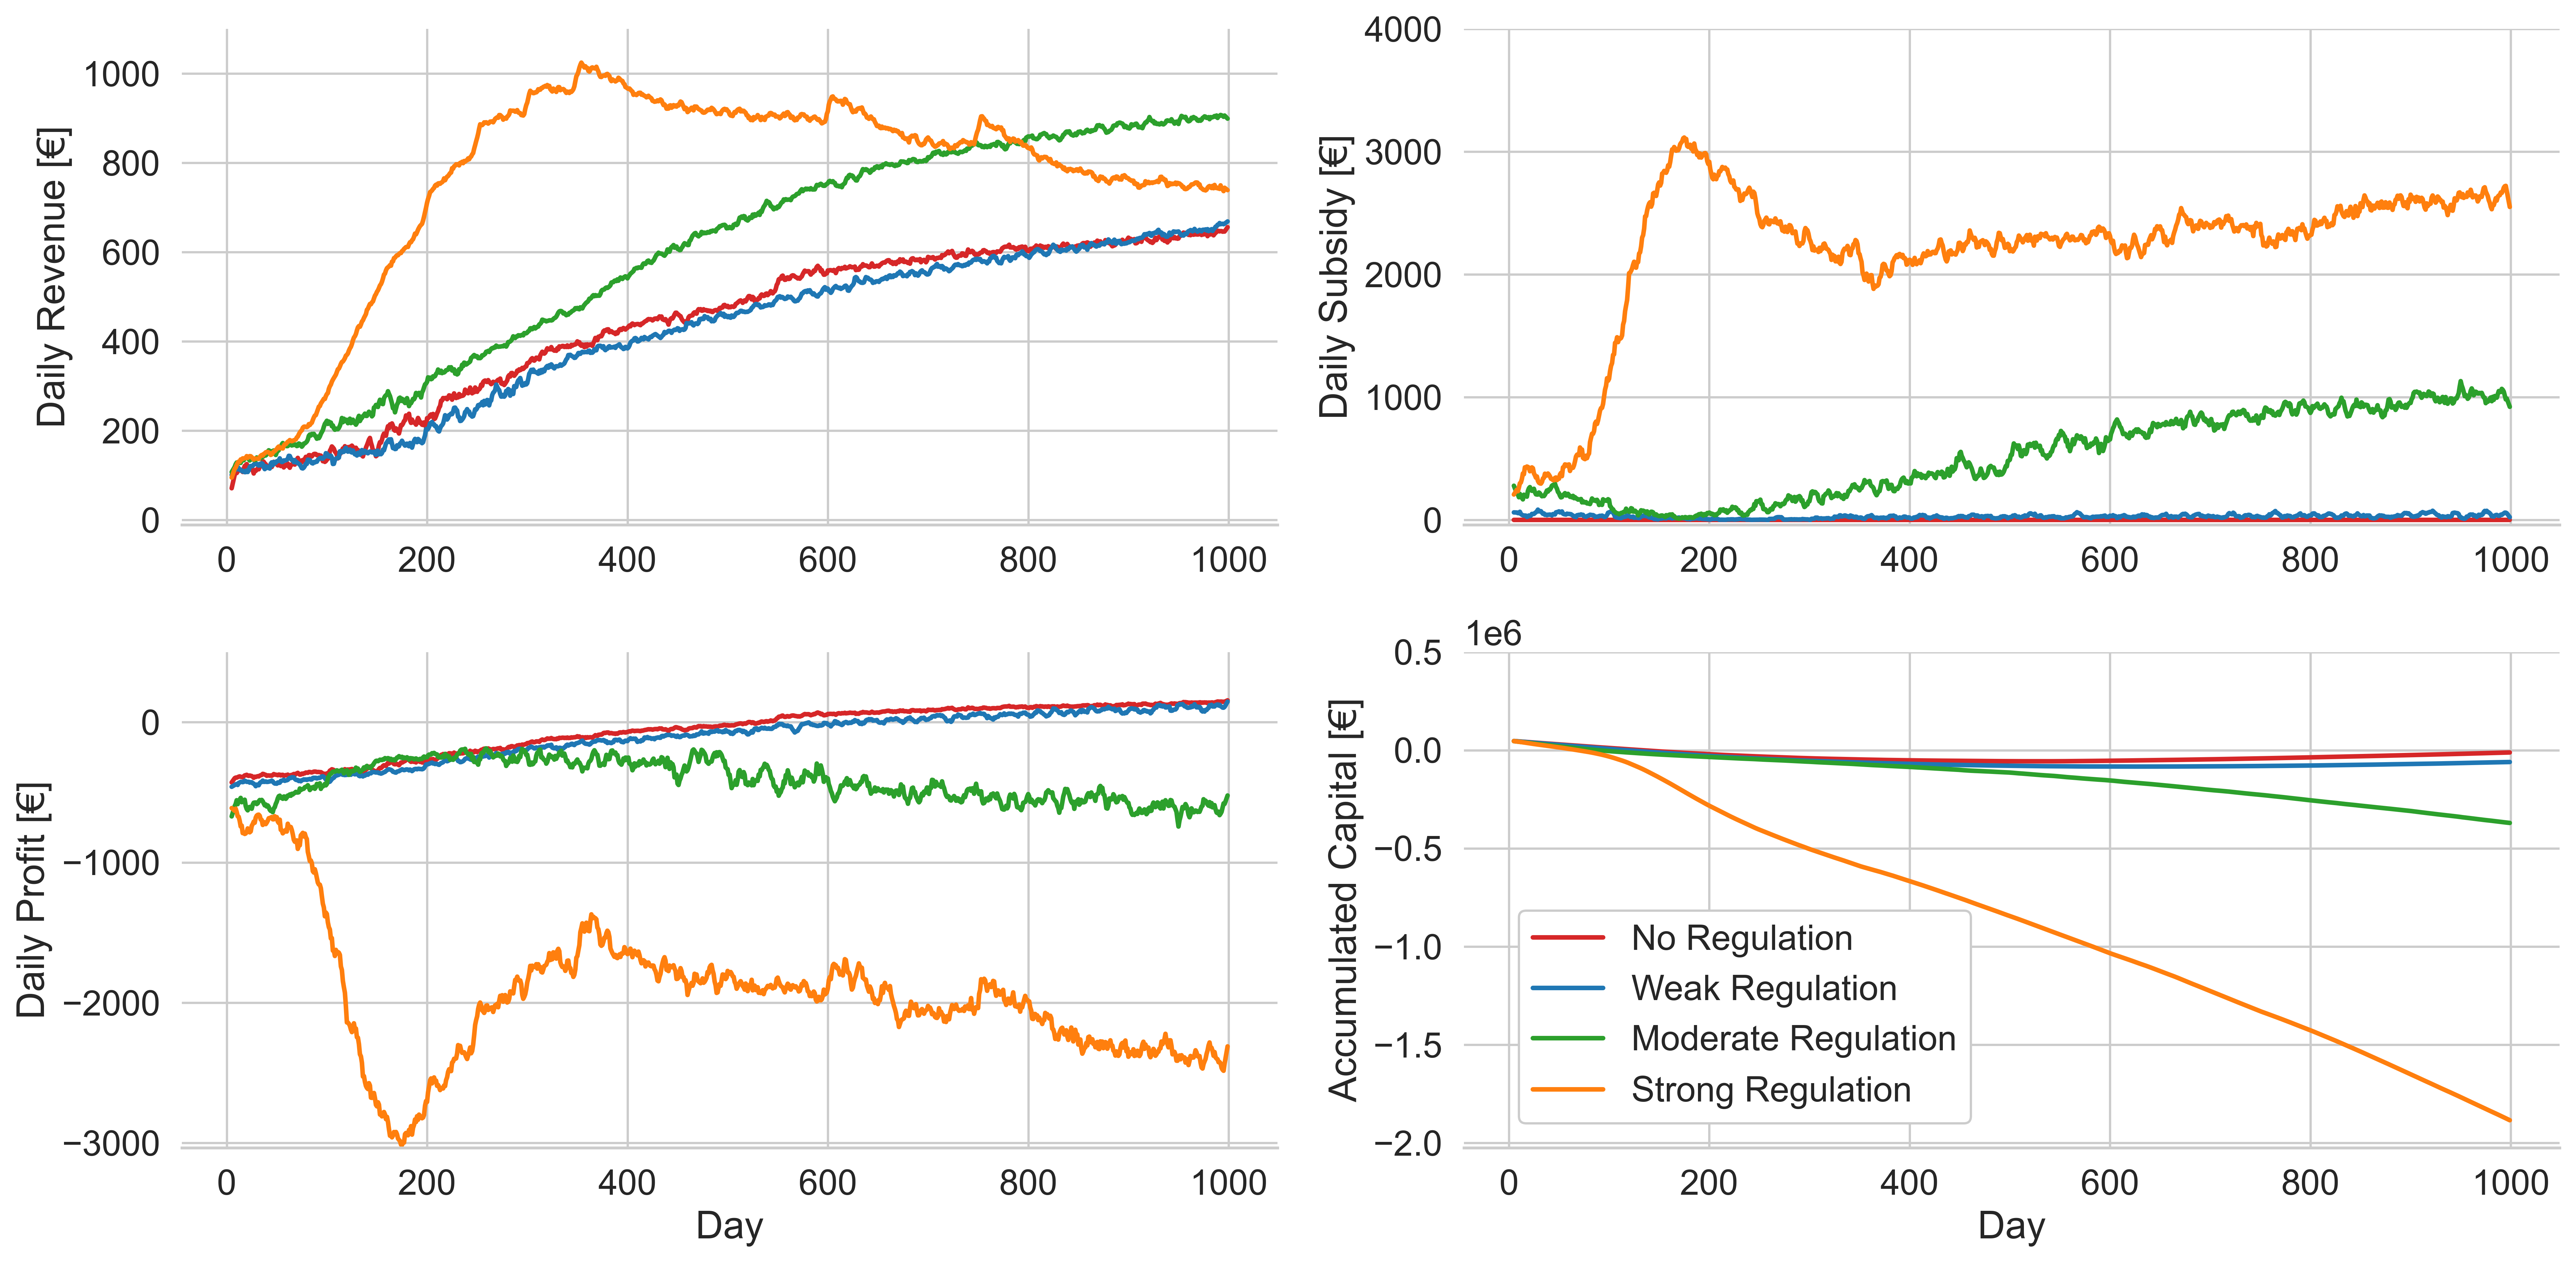

In [8]:
# With no lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_revenue+d_nr.P2_revenue)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_revenue+d_wr.P2_revenue)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_revenue+d_mr.P2_revenue)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_revenue+d_sr.P2_revenue)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])

ax[0][0].set(xlabel='', ylabel='Daily Revenue [€]', ylim = (-11, 1100))
ax[0][0].legend().remove()

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_min_wage_sub+d_nr.P2_min_wage_sub)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_min_wage_sub+d_wr.P2_min_wage_sub)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_min_wage_sub+d_mr.P2_min_wage_sub)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_min_wage_sub+d_sr.P2_min_wage_sub)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Daily Subsidy [€]', ylim = (-40, 4000))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_profit+d_nr.P2_profit)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_profit+d_wr.P2_profit)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_profit+d_mr.P2_profit)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_profit+d_sr.P2_profit)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Daily Profit [€]', ylim = (-3035, 500))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_remaining_capital+d_nr.P2_remaining_capital)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wr.index, y=s_1((d_wr.P1_remaining_capital+d_wr.P2_remaining_capital)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mr.index, y=s_1((d_mr.P1_remaining_capital+d_mr.P2_remaining_capital)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_sr.index, y=s_1((d_sr.P1_remaining_capital+d_sr.P2_remaining_capital)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Accumulated Capital [€]', ylim = (-2025000, 500000))

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.05,0.05))
plt.tight_layout()
# plt.savefig('Figs/1.2/P3_fig2.png')

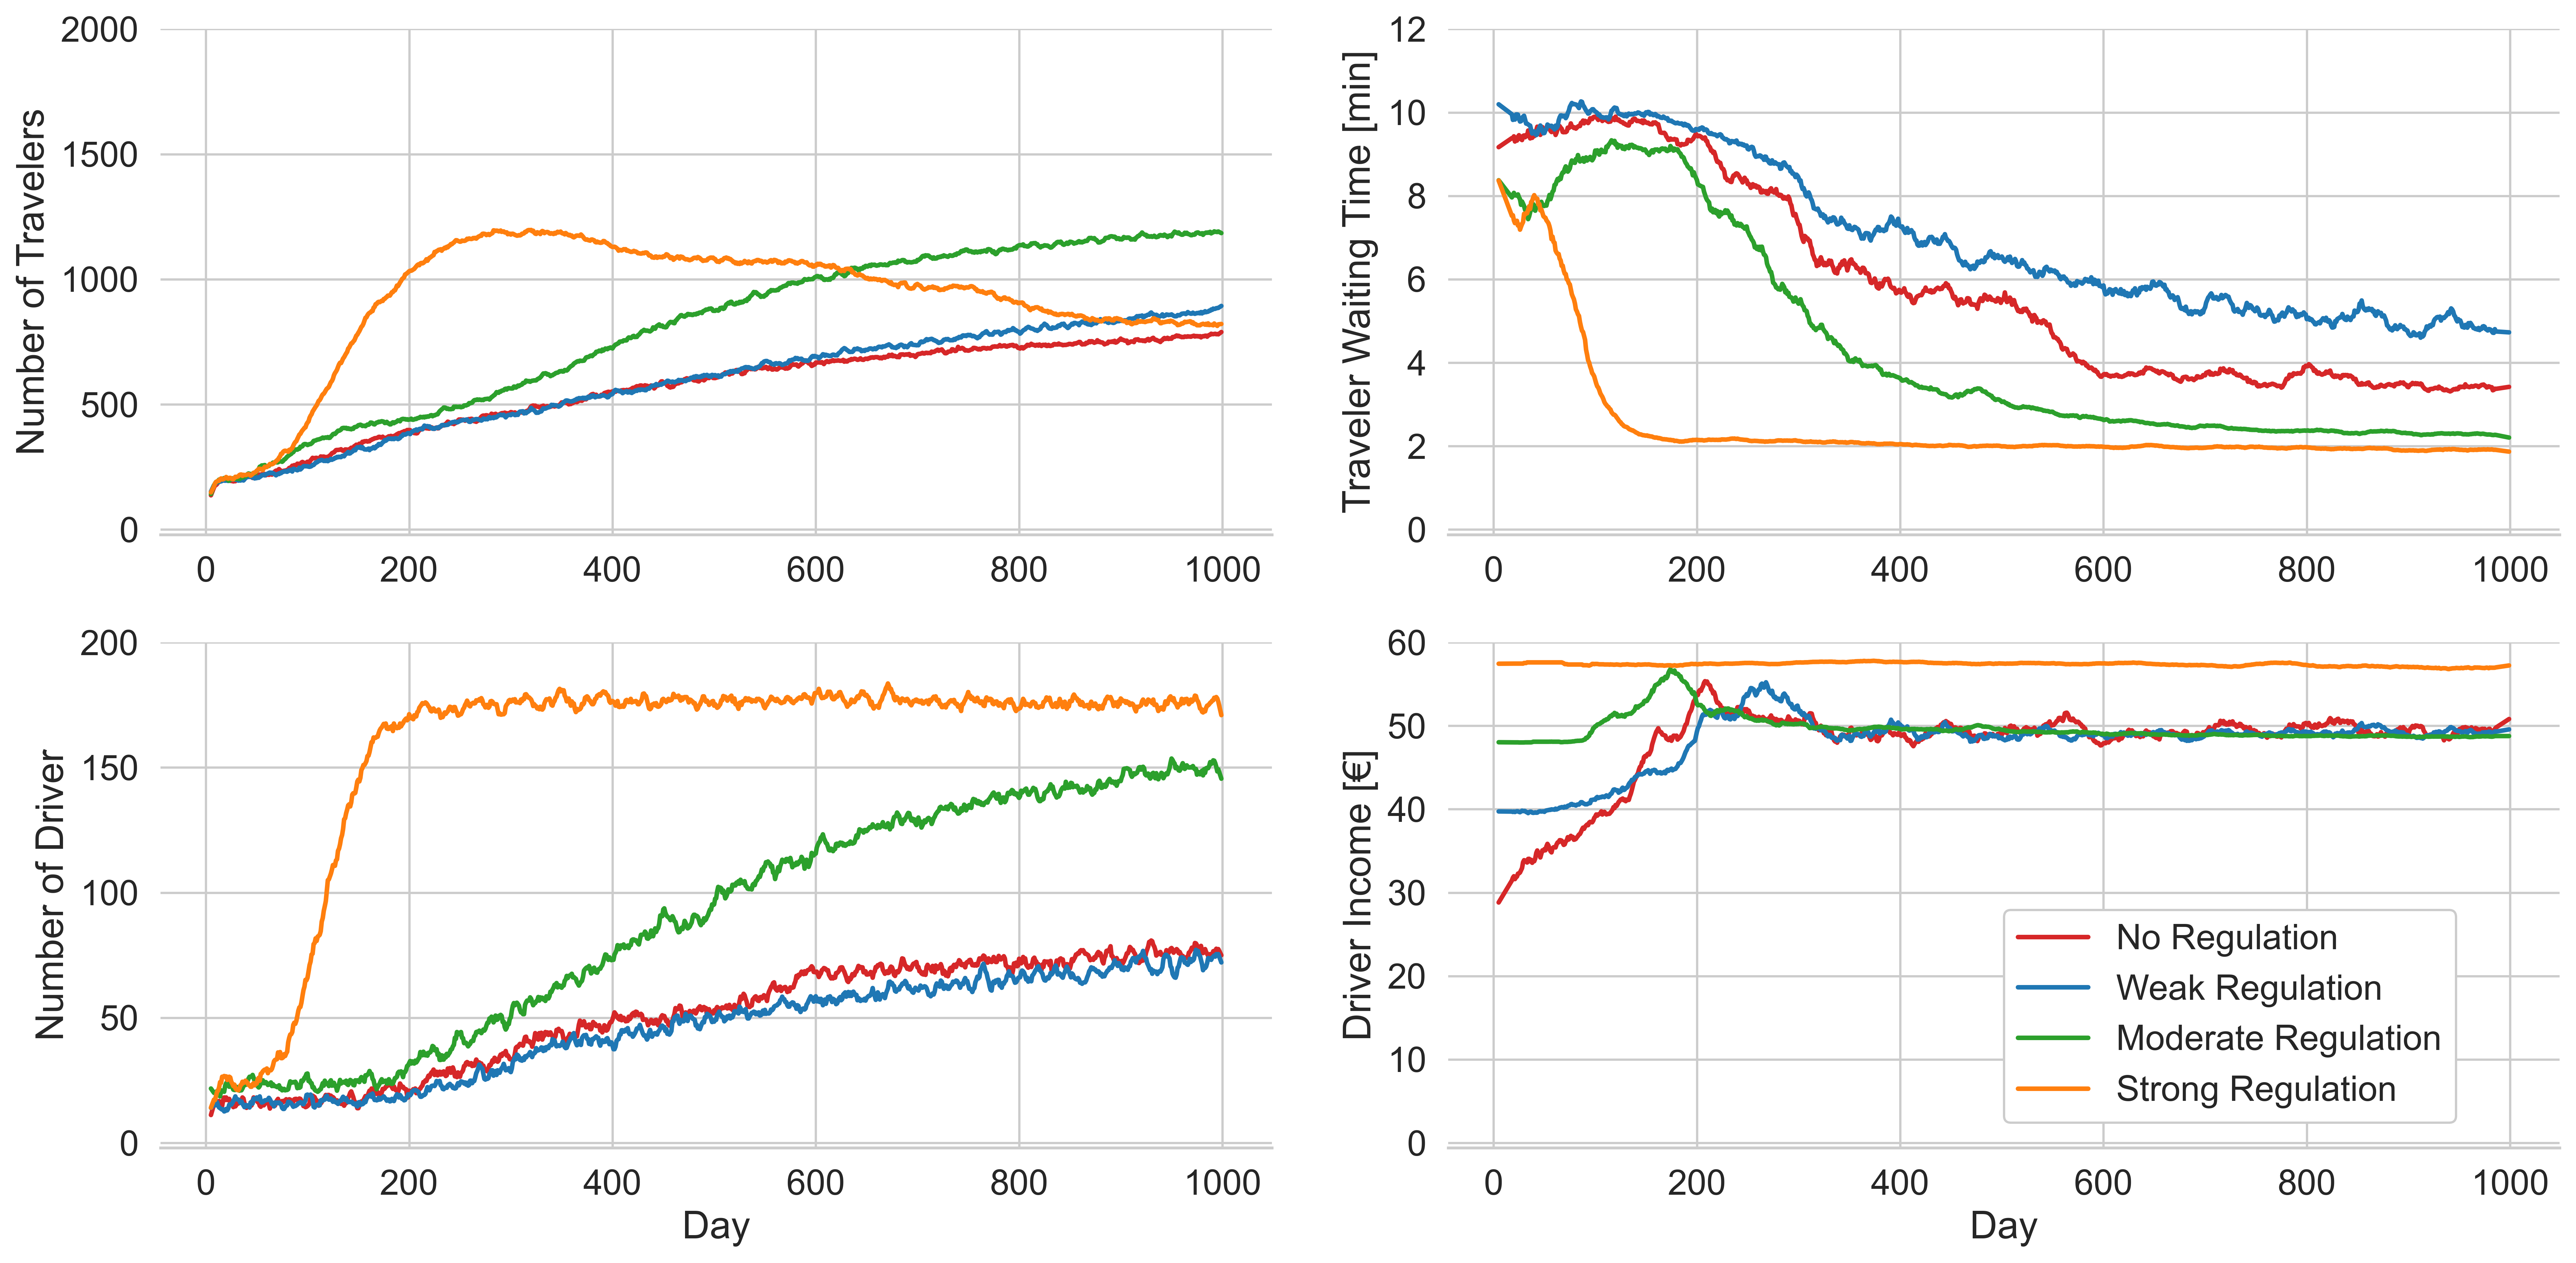

In [26]:
# With no lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1(d_nr.P1_OUT+d_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wr.index, y=s_1(d_wr.P1_OUT+d_wr.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mr.index, y=s_1(d_mr.P1_OUT+d_mr.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_sr.index, y=s_1(d_sr.P1_OUT+d_sr.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])
ax[0][0].legend().remove()

ax[0][0].set(xlabel='', ylabel='Number of Travelers', ylim = (-20, 2000))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_2(((d_nr.P1_OUT*d_nr.P1_ACTUAL_WT)+(d_nr.P2_OUT*d_nr.P2_ACTUAL_WT))/(d_nr.P1_OUT+d_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wr.index, y=s_2(((d_wr.P1_OUT*d_wr.P1_ACTUAL_WT)+(d_wr.P2_OUT*d_wr.P2_ACTUAL_WT))/(d_wr.P1_OUT+d_wr.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mr.index, y=s_2(((d_mr.P1_OUT*d_mr.P1_ACTUAL_WT)+(d_mr.P2_OUT*d_mr.P2_ACTUAL_WT))/(d_mr.P1_OUT+d_mr.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_sr.index, y=s_2(((d_sr.P1_OUT*d_sr.P1_ACTUAL_WT)+(d_sr.P2_OUT*d_sr.P2_ACTUAL_WT))/(d_sr.P1_OUT+d_sr.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Traveler Waiting Time [min]', ylim = (-0.12, 12))

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_1(s_nr.P1_OUT+s_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_wr.index, y=s_1(s_wr.P1_OUT+s_wr.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_mr.index, y=s_1(s_mr.P1_OUT+s_mr.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_sr.index, y=s_1(s_sr.P1_OUT+s_sr.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Number of Driver', ylim = (-2, 200))

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_2(((s_nr.P1_OUT*s_nr.P1_ACTUAL_INC)+(s_nr.P2_OUT*s_nr.P2_ACTUAL_INC))/(s_nr.P1_OUT+s_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_wr.index, y=s_2(((s_wr.P1_OUT*s_wr.P1_ACTUAL_INC)+(s_wr.P2_OUT*s_wr.P2_ACTUAL_INC))/(s_wr.P1_OUT+s_wr.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_mr.index, y=s_2(((s_mr.P1_OUT*s_mr.P1_ACTUAL_INC)+(s_mr.P2_OUT*s_mr.P2_ACTUAL_INC))/(s_mr.P1_OUT+s_mr.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_sr.index, y=s_2(((s_sr.P1_OUT*s_sr.P1_ACTUAL_INC)+(s_sr.P2_OUT*s_sr.P2_ACTUAL_INC))/(s_sr.P1_OUT+s_sr.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Driver Income [€]', ylim = (-0.6, 60))

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.5,0.05))
plt.tight_layout()
plt.savefig('Figs/1.2/P3_fig3.png')

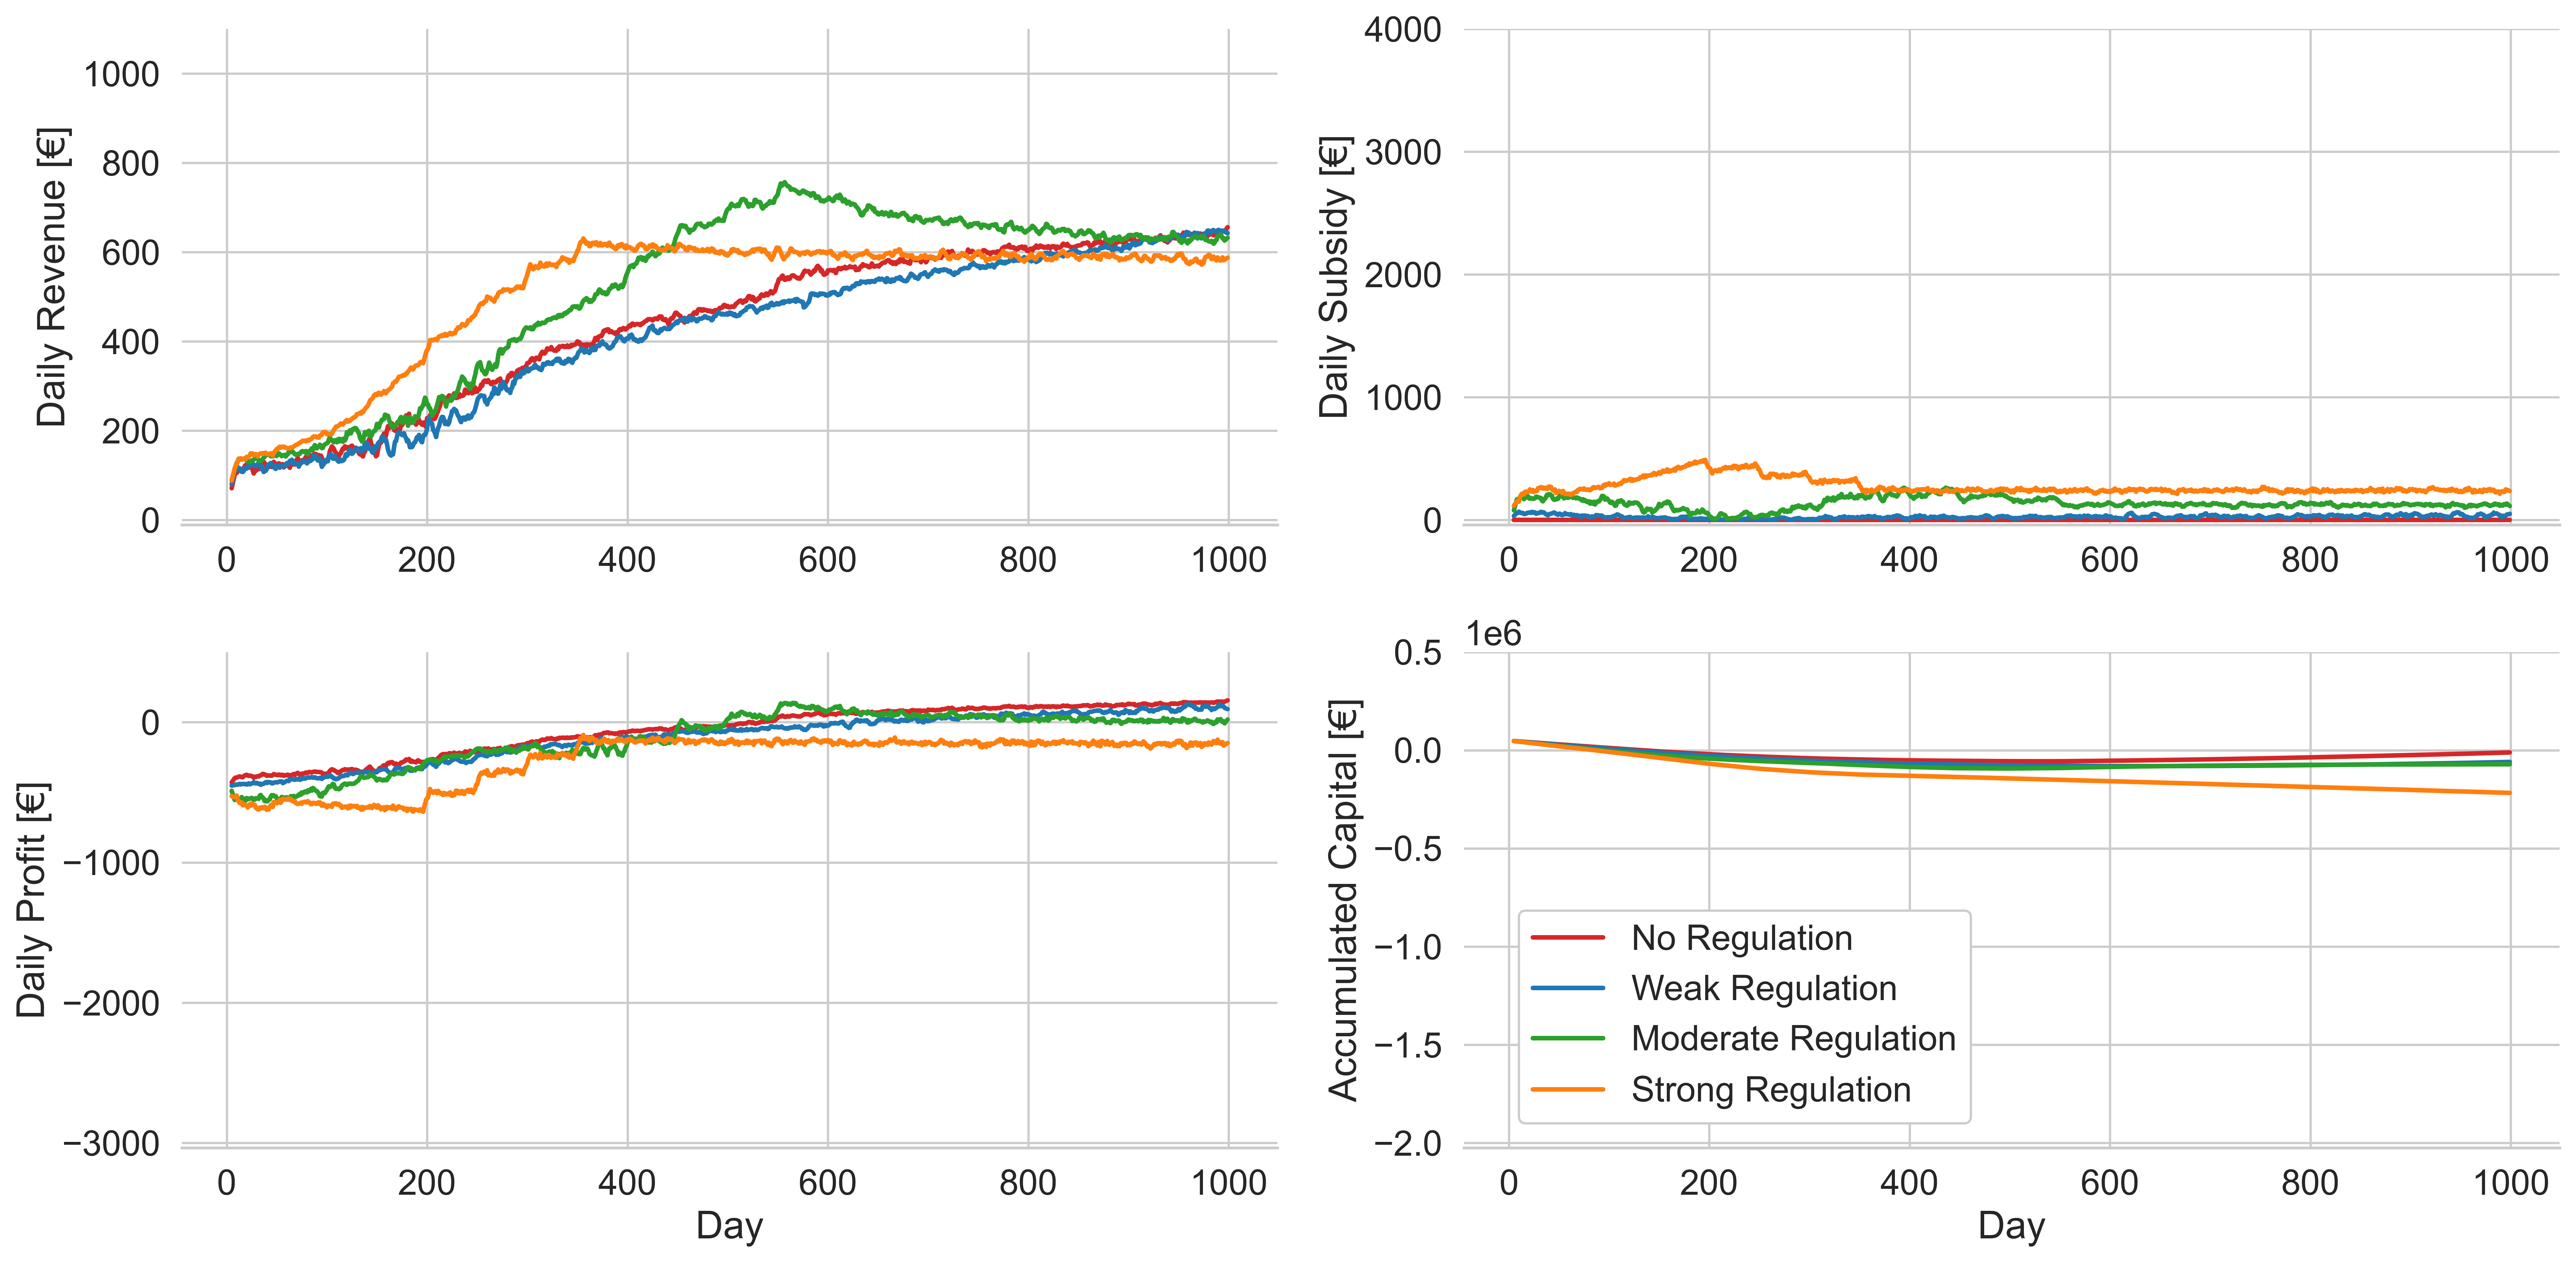

In [27]:
# With lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_revenue+d_nr.P2_revenue)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_revenue+d_wrl.P2_revenue)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_revenue+d_mrl.P2_revenue)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_revenue+d_srl.P2_revenue)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])

ax[0][0].set(xlabel='', ylabel='Daily Revenue [€]', ylim = (-11, 1100))
ax[0][0].legend().remove()

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_min_wage_sub+d_nr.P2_min_wage_sub)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_min_wage_sub+d_wrl.P2_min_wage_sub)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_min_wage_sub+d_mrl.P2_min_wage_sub)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_min_wage_sub+d_srl.P2_min_wage_sub)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Daily Subsidy [€]', ylim = (-40, 4000))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_profit+d_nr.P2_profit)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_profit+d_wrl.P2_profit)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_profit+d_mrl.P2_profit)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_profit+d_srl.P2_profit)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Daily Profit [€]', ylim = (-3035, 500))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_1((d_nr.P1_remaining_capital+d_nr.P2_remaining_capital)/2), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_wrl.index, y=s_1((d_wrl.P1_remaining_capital+d_wrl.P2_remaining_capital)/2), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_mrl.index, y=s_1((d_mrl.P1_remaining_capital+d_mrl.P2_remaining_capital)/2), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=d_srl.index, y=s_1((d_srl.P1_remaining_capital+d_srl.P2_remaining_capital)/2), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Accumulated Capital [€]', ylim = (-2025000, 500000))

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.05,0.05))
plt.tight_layout()
plt.savefig('Figs/1.2/P3_fig4.png')

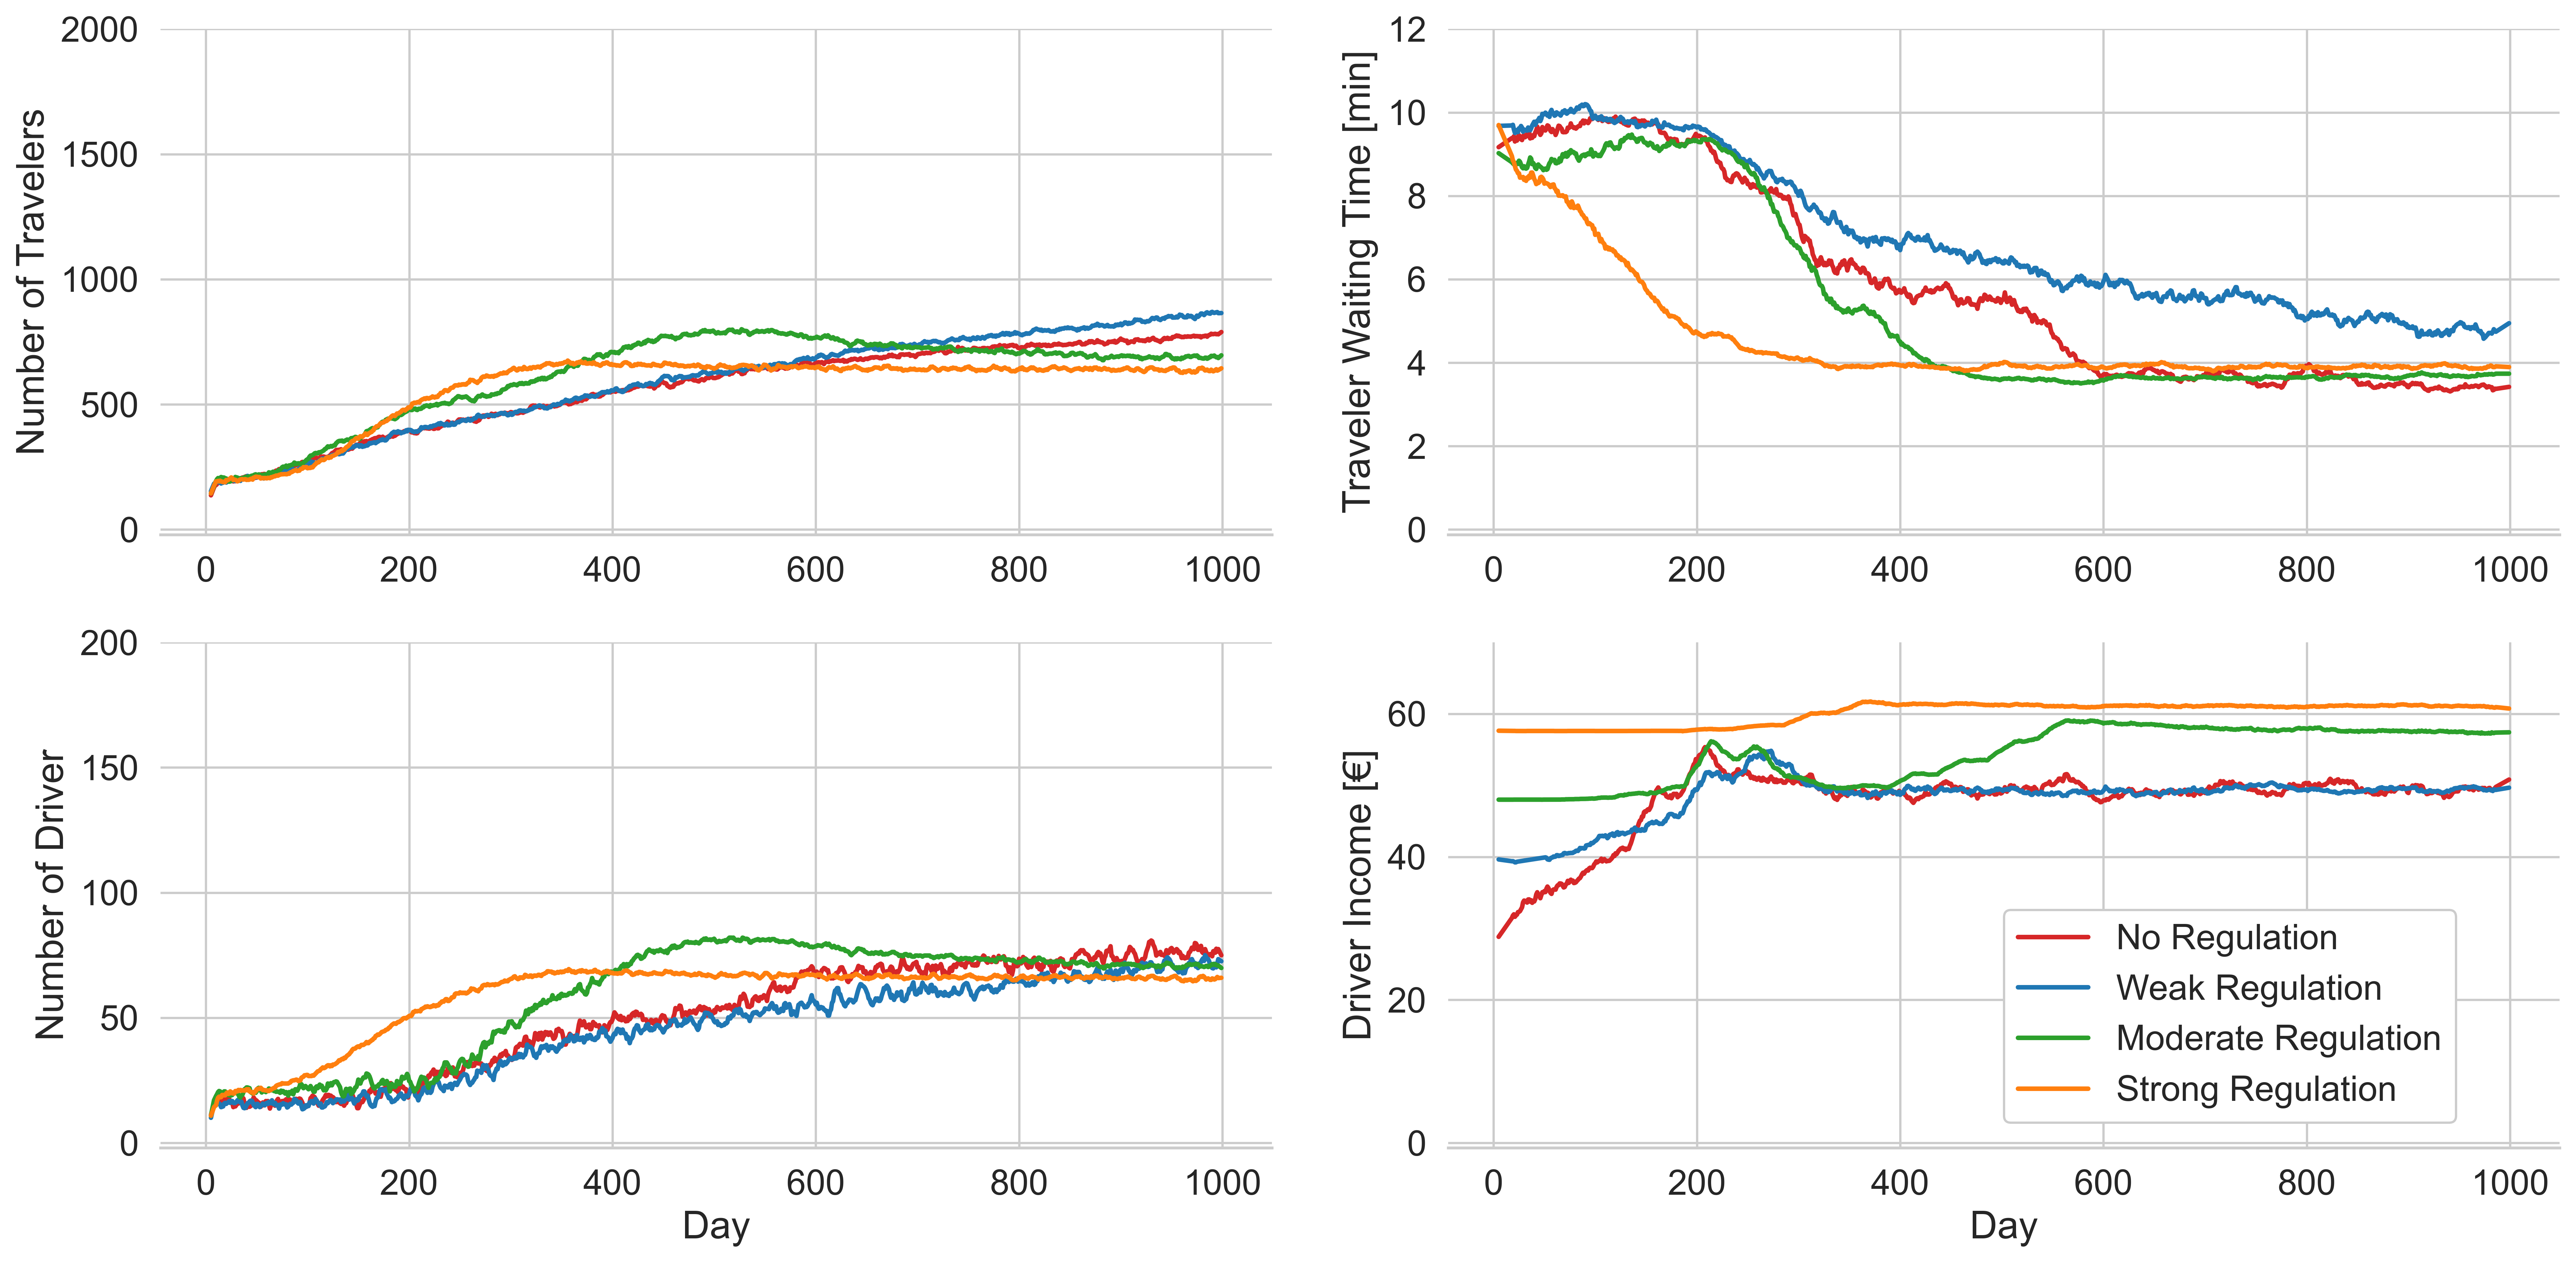

In [28]:
# With lockout

sns.set(rc={"figure.dpi":500, 'savefig.dpi':500})
sns.set(palette='tab10',font_scale=1.4)#, rc={'axes.facecolor':'lightblue', 'figure.facecolor':'lightgreen'},)
sns.set_style('whitegrid')
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))
sns.despine(left=True)

c1 = 'C3'; c2 = 'C0'; c3 = 'C2'; c4 = 'C1'
lw = 2

sns.lineplot(x=d_nr.index, y=s_1(d_nr.P1_OUT+d_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_wrl.index, y=s_1(d_wrl.P1_OUT+d_wrl.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_mrl.index, y=s_1(d_mrl.P1_OUT+d_mrl.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][0])
sns.lineplot(x=d_srl.index, y=s_1(d_srl.P1_OUT+d_srl.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][0])
ax[0][0].legend().remove()

ax[0][0].set(xlabel='', ylabel='Number of Travelers', ylim = (-20, 2000))

#------------------------------------------------

sns.lineplot(x=d_nr.index, y=s_2(((d_nr.P1_OUT*d_nr.P1_ACTUAL_WT)+(d_nr.P2_OUT*d_nr.P2_ACTUAL_WT))/(d_nr.P1_OUT+d_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_wrl.index, y=s_2(((d_wrl.P1_OUT*d_wrl.P1_ACTUAL_WT)+(d_wrl.P2_OUT*d_wrl.P2_ACTUAL_WT))/(d_wrl.P1_OUT+d_wrl.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_mrl.index, y=s_2(((d_mrl.P1_OUT*d_mrl.P1_ACTUAL_WT)+(d_mrl.P2_OUT*d_mrl.P2_ACTUAL_WT))/(d_mrl.P1_OUT+d_mrl.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[0][1])
sns.lineplot(x=d_srl.index, y=s_2(((d_srl.P1_OUT*d_srl.P1_ACTUAL_WT)+(d_srl.P2_OUT*d_srl.P2_ACTUAL_WT))/(d_srl.P1_OUT+d_srl.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[0][1])
ax[0][1].legend().remove()

ax[0][1].set(xlabel='', ylabel='Traveler Waiting Time [min]', ylim = (-0.12, 12))

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_1(s_nr.P1_OUT+s_nr.P2_OUT), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_wrl.index, y=s_1(s_wrl.P1_OUT+s_wrl.P2_OUT), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_mrl.index, y=s_1(s_mrl.P1_OUT+s_mrl.P2_OUT), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][0])
sns.lineplot(x=s_srl.index, y=s_1(s_srl.P1_OUT+s_srl.P2_OUT), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][0])
ax[1][0].legend().remove()

ax[1][0].set(xlabel='Day', ylabel='Number of Driver', ylim = (-2, 200))

#------------------------------------------------

sns.lineplot(x=s_nr.index, y=s_2(((s_nr.P1_OUT*s_nr.P1_ACTUAL_INC)+(s_nr.P2_OUT*s_nr.P2_ACTUAL_INC))/(s_nr.P1_OUT+s_nr.P2_OUT)), label = 'No Regulation', color=c1, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_wrl.index, y=s_2(((s_wrl.P1_OUT*s_wrl.P1_ACTUAL_INC)+(s_wrl.P2_OUT*s_wrl.P2_ACTUAL_INC))/(s_wrl.P1_OUT+s_wrl.P2_OUT)), label = 'Weak Regulation', color=c2, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_mrl.index, y=s_2(((s_mrl.P1_OUT*s_mrl.P1_ACTUAL_INC)+(s_mrl.P2_OUT*s_mrl.P2_ACTUAL_INC))/(s_mrl.P1_OUT+s_mrl.P2_OUT)), label = 'Moderate Regulation', color=c3, lw=lw, ax=ax[1][1])
sns.lineplot(x=s_srl.index, y=s_2(((s_srl.P1_OUT*s_srl.P1_ACTUAL_INC)+(s_srl.P2_OUT*s_srl.P2_ACTUAL_INC))/(s_srl.P1_OUT+s_srl.P2_OUT)), label = 'Strong Regulation', color=c4, lw=lw, ax=ax[1][1])
ax[1][1].legend().remove()

ax[1][1].set(xlabel='Day', ylabel='Driver Income [€]', ylim = (-0.7, 70))

#-------------------------------------------------

ax[1][1].legend(frameon=True,framealpha=1, loc=(0.5,0.05))
plt.tight_layout()
plt.savefig('Figs/1.2/P3_fig5.png')

In [ ]:
# No regulation
d_nr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital'))
s_nr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital'))

# Weak regulation
d_wr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_low_sub'))
s_wr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_low_sub'))
# Weak regulation with lockout
d_wrl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_low_sub_lockout'))
s_wrl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_low_sub_lockout'))

# Moderate regulation
d_mr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_moderate_sub'))
s_mr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_moderate_sub'))
# Moderate regulation with lockout
d_mrl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_moderate_sub_lockout'))
s_mrl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_moderate_sub_lockout'))

# Strong regulation
d_sr = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_high_sub'))
s_sr = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_high_sub'))
# Strong regulation with lockout
d_srl = pd.read_csv('csv/1.1/demand_{}_1_1.csv'.format('capital_with_high_sub_lockout'))
s_srl = pd.read_csv('csv/1.1/supply_{}_1_1.csv'.format('capital_with_high_sub_lockout'))

In [ ]:
sns.set(rc={"figure.dpi": 500, 'savefig.dpi': 500})
sns.set(palette='tab10', font_scale=1.0)
sns.set_style('white')
fig, ax = plt.subplots(figsize=(8, 5))

c1 = 'C9'; c2 = 'C1'

groups = ['Driver', 'Traveler', 'Platform']
weak_regulation = [-0.6, -42.81, -23.96]
moderate_regulation = [-1.58, 33.26, -555.02]
strong_regulation = [15.11, 44.11, -1850.64] # None for the "No regulation" group where there is no "with lockout"

x = np.arange(len(groups))  # The label locations


width = 0.3  # Width of the bars

bars_without_lockout = ax.bar(x - width/2, values_without_lockout, width, label='Without Lockout', color=c1)

# Plot bars for "with lockout", skipping the first group
bars_with_lockout = [
    ax.bar(pos + width/2, value, width, color=c2, label='With Lockout' if i == 0 else "")
    for i, (pos, value) in enumerate(zip(x, values_with_lockout)) if value is not None
]

handles = [
    plt.Line2D([0], [0], color=c1, lw=8, label='Without Lockout'),
    plt.Line2D([0], [0], color=c2, lw=8, label='With Lockout')
]
ax.legend(handles=handles)
ax.set(xlabel='', ylabel='Trip Fare [€/km]', ylim=(0.0, 2.0))
ax.set_yticks(np.arange(0, 2.1, 0.2))
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(groups)

plt.tight_layout()

In [ ]:
groups = ['Driver', 'Traveler', 'Platform']

# agent = [no_reg, weak_reg, moderate_reg, strong_reg]

driver = [49.92, 48.87, 48.76, 56.73]
traveler = [3.54, 4.38, 2.36, 1.97]
platform = [221.99, 234.11, -584.33, -2371.64]
Fare =[1.4, 1.2, 1.2, 1.6] 

driverl = [49.92, 49.20, 56.99, 61.14]
travelerl = [3.54, 4.21, 3.81, 3.85]
platforml = [221.99, 251.96, -28.81, -171.80]
Farel =[1.4, 1.2, 1.6, 1.6] 

In [ ]:
groups = ['Driver', 'Traveler', 'Platform']

# without Lockout
weak_regulation = [-0.6, -42.81, -23.96]
moderate_regulation = [-1.58, 33.26, -555.02]
strong_regulation = [15.11, 44.11, -1850.64]

# with Lockout
weak_regulation = [-0.13, -39.46, 28.12]
moderate_regulation = [16.12, -8.69, -92.86]
strong_regulation = [23.45, -14.41, -214.32]

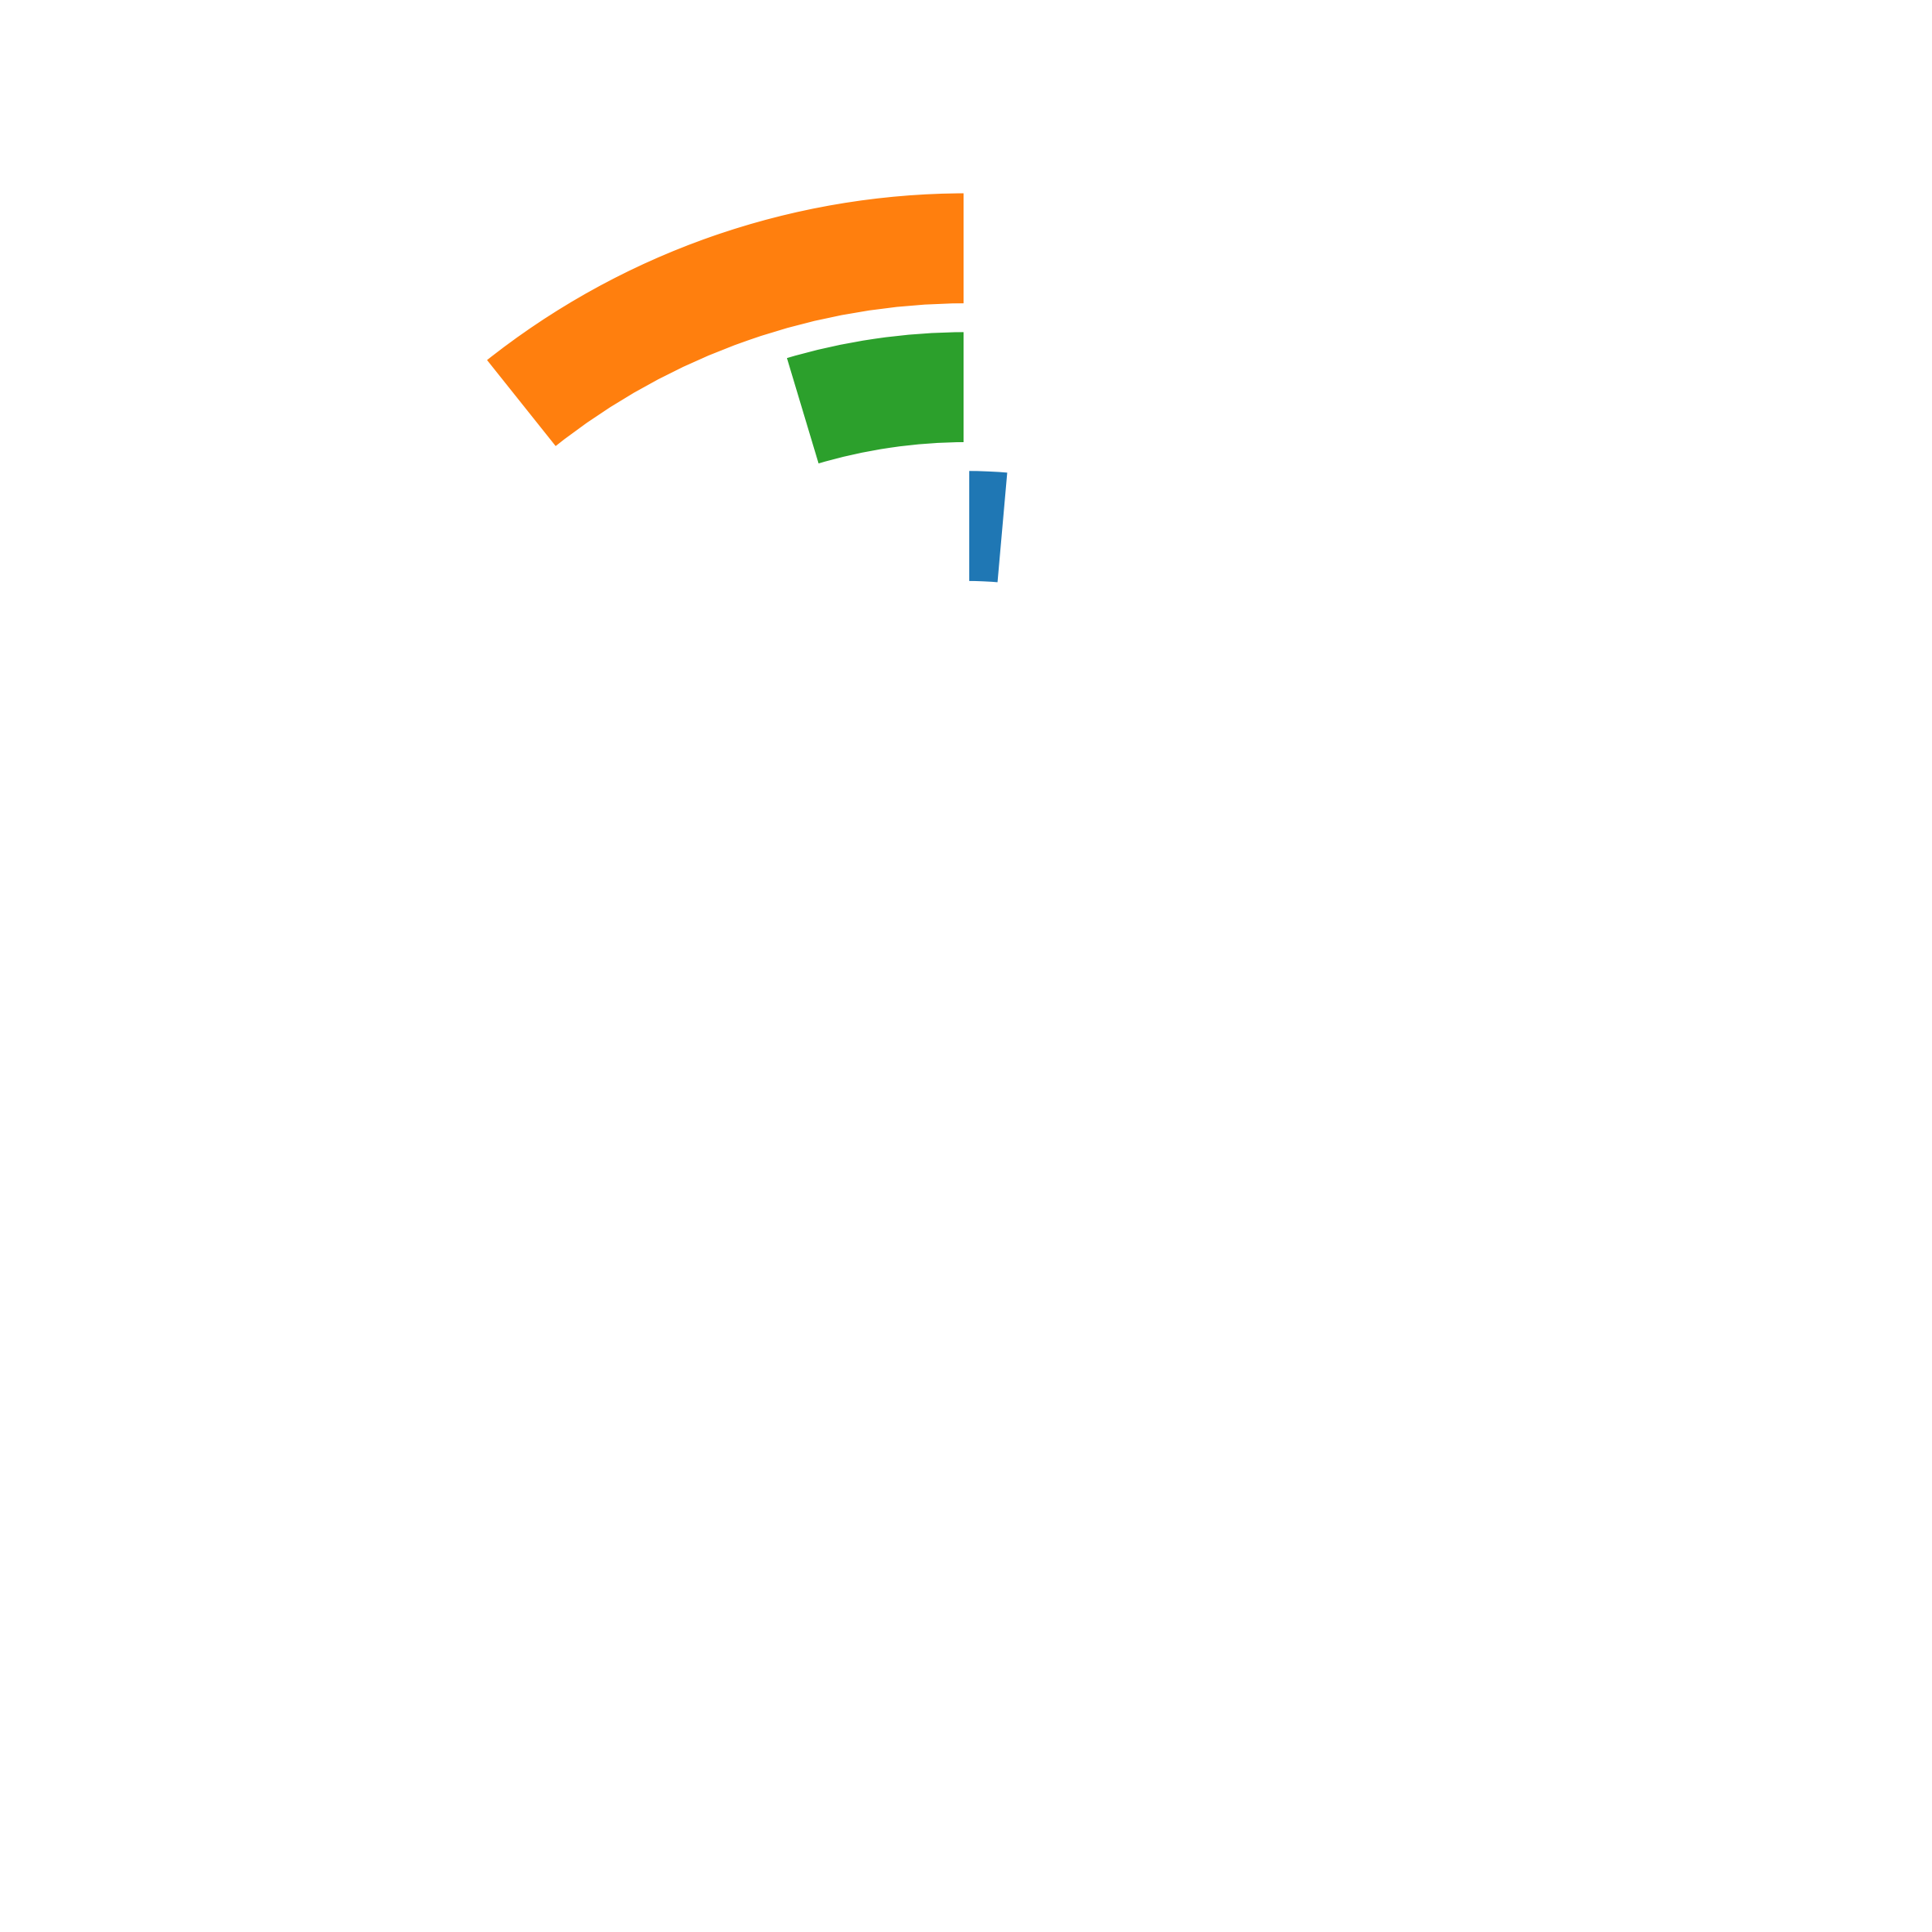

In [247]:
from math import pi
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(6, 6))
ax = plt.subplot(projection='polar')
data = [28.12, -92.86, -214.32]
data = [-i/20 for i in data]
startangle = 90

colors = ['C0', 'C2', 'C1']
xs = [(i * pi *2)/ 100 for i in data]
ys = [-0.2, 1, 2.2]
left = (startangle * pi *2)/ 360 #this is to control where the bar starts

# plot bars and points at the end to make them round
for i, x in enumerate(xs):
    ax.barh(ys[i], x, left=left, height=1, color=colors[i])
    
plt.ylim(-4, 4)
# clear ticks, grids, spines
plt.xticks([])
plt.yticks([])
ax.spines.clear()
plt.savefig('Figs/1.2/P3_fig_PL.png')

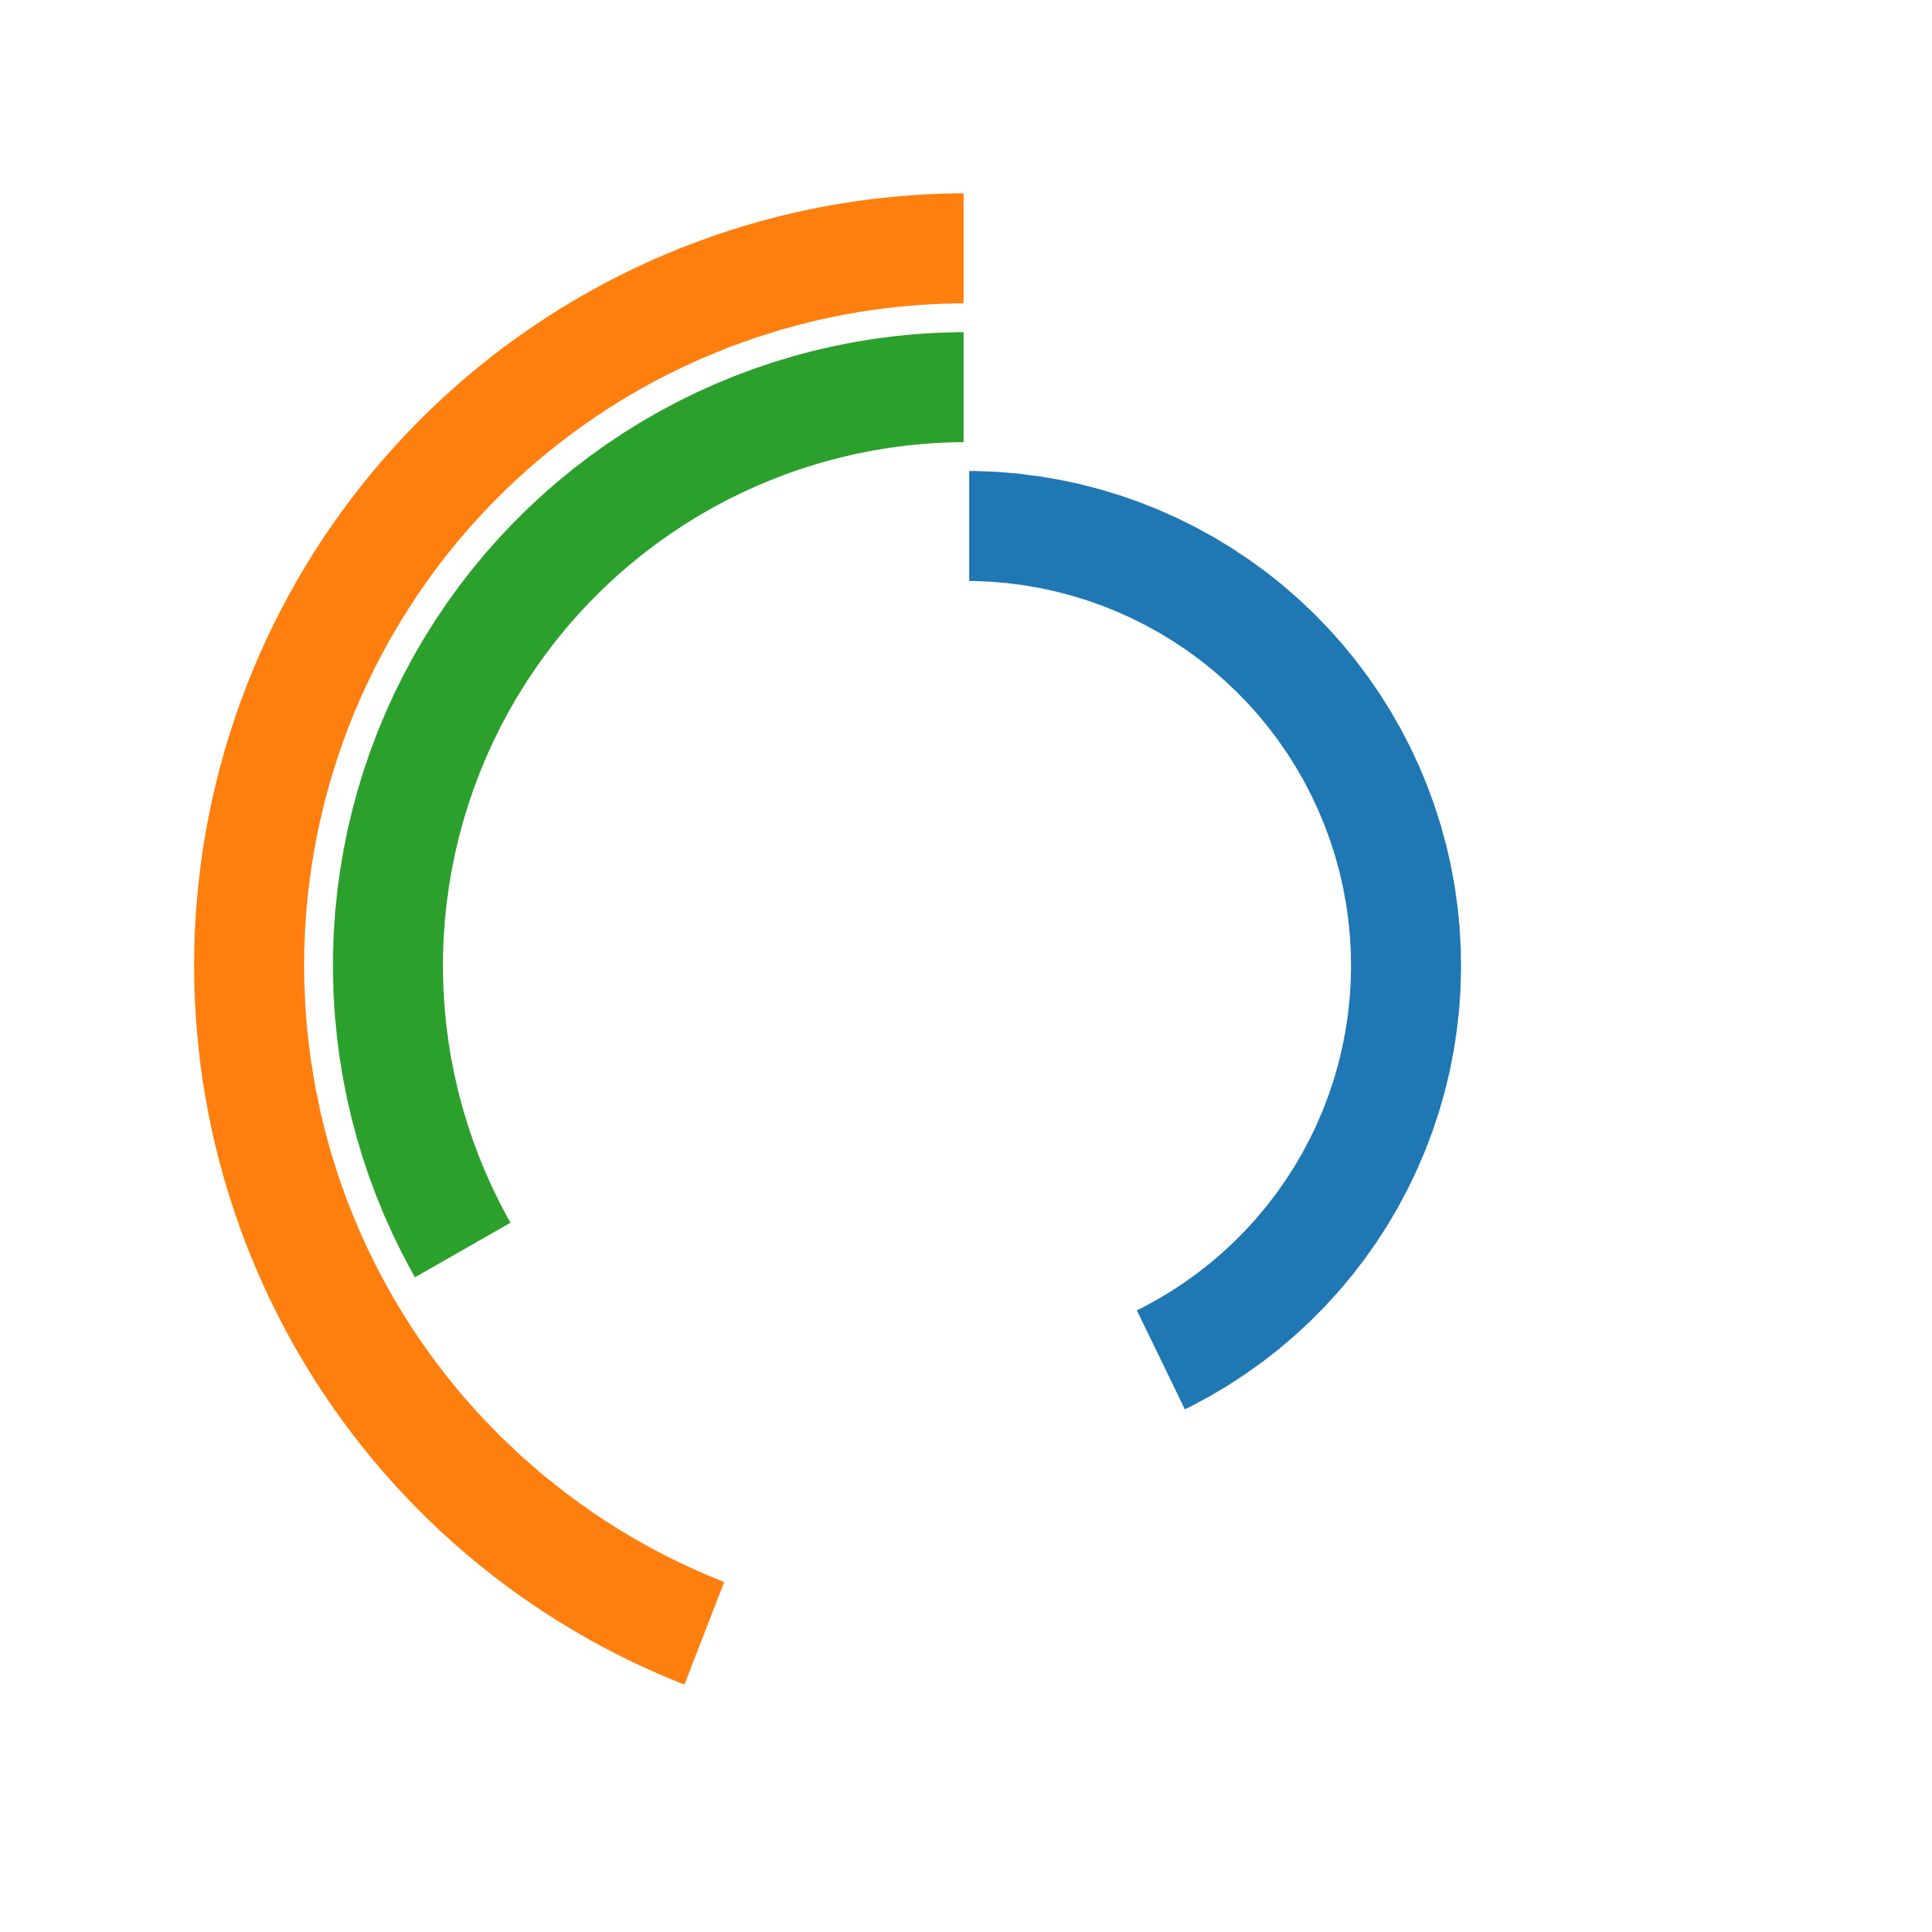

In [229]:
from math import pi, degrees
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

data = [-42.81, 33.26, 44.11]  # Percentage values
startangle = 90
colors = ['C0', 'C2', 'C1']

# Convert data percentages to radians
xs = [(val * 2 * pi) / 100 for val in data]
ys = [-0.2, 1, 2.2]
left = (startangle * 2 * pi) / 360  # Starting angle in radians
lefts = [left+0.03, left-0.35, left]

for i, (x, val) in enumerate(zip(xs, data)):
    # Draw the bars
    ax.barh(ys[i], x, left=left, height=1, color=colors[i])

    # Place text at the starting angle (left) instead of the end
    # ax.text(
    #     lefts[i], ys[i],  # Position next to the starting point
    #     f"{val:.2f}%",  # Format as percentage
    #     ha="right", va="center",  # Align text properly
    #     fontsize=10, color='black', fontweight='bold'  # Rotate text to match starting angle
    # )

plt.ylim(-4, 4)

# Remove ticks and spines for a clean look
plt.xticks([])
plt.yticks([])
ax.spines.clear()

# plt.savefig('Figs/1.2/P3_fig_t.png')
plt.show()


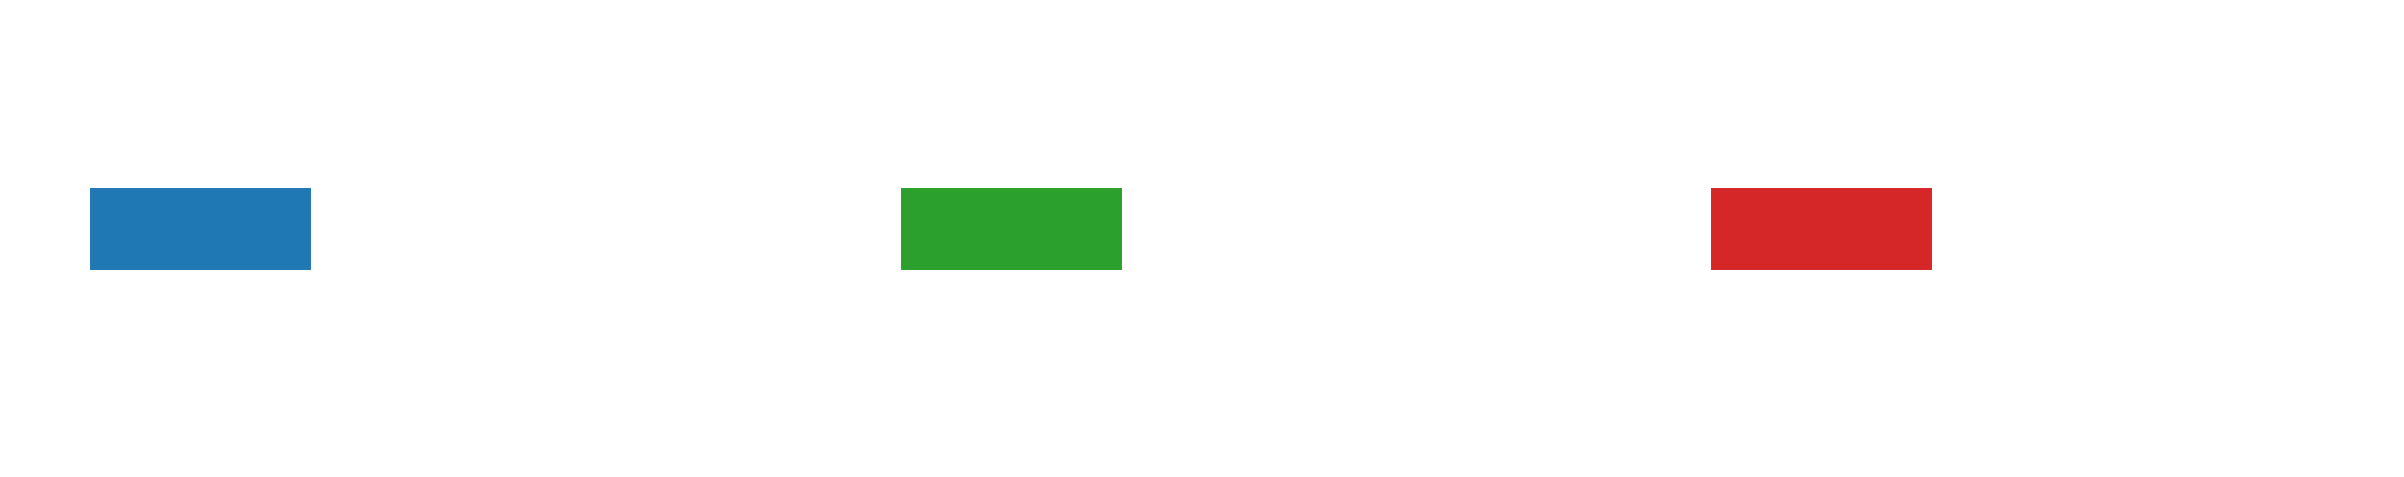

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define colors and labels
colors = ['C0', 'C2', 'C3']
labels = ['          ', '          ', '          ']  # Customize as needed

# Create legend handles
legend_patches = [mpatches.Patch(color=col, label=lab) for col, lab in zip(colors, labels)]

# Create the figure and legend
plt.figure(figsize=(4, 1))  # Wider figure for horizontal layout
plt.legend(handles=legend_patches, loc='center', frameon=False, ncol=len(colors), 
           title="", title_fontsize=11)  # Add title

plt.axis('off')  # Hide axes

# Show the legend
plt.savefig('Figs/1.3/P3_fig_legend.png')